# Similarity-Pruned Dataset Workflow

Select one random anchor graph, compute vectorized embeddings for all graphs,
define a regression target as cosine similarity to that anchor,
remove the top-`k` most similar graphs, and continue with the pruned dataset.


In [28]:
%matplotlib inline
import math
import hashlib
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from NSPPK.nsppk import NSPPK

from coco_grape.visualizer.mol_display import draw_molecules


In [29]:
def plot_networkx_graphs(graphs, cmap='tab20', light=0.4, size=3.5, n_cols=None, show_label=True, color_offset=200, mode='not_molecule'):
    if len(graphs) == 0:
        print("No graphs to display.")
        return

    if mode == 'molecule':
        draw_molecules(graphs)
        return

    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)

    def lighten_color(color, amount):
        return tuple(channel + (1 - channel) * amount for channel in color[:3])

    def color_for_label(label):
        digest = hashlib.md5(str(label).encode("utf-8")).hexdigest()
        idx = (int(digest, 16) + color_offset) % cmap.N
        return lighten_color(cmap(idx), light)

    n_graphs = len(graphs)
    if n_cols is None:
        n_cols = n_graphs
    n_rows = math.ceil(n_graphs / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(size * n_cols, size * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    elif n_rows == 1 or n_cols == 1:
        axes = np.array(axes).reshape(-1)
    else:
        axes = np.array(axes).reshape(-1)

    for i, graph in enumerate(graphs):
        ax = axes[i]
        labels = [graph.nodes[n].get('label', '?') for n in graph.nodes()]
        node_colors = [color_for_label(lbl) for lbl in labels]
        pos = nx.spring_layout(graph, seed=42)
        nx.draw_networkx(graph, pos=pos, node_color=node_colors, ax=ax, with_labels=show_label, font_size=8)
        ax.set_axis_off()

    for j in range(i + 1, len(axes)):
        axes[j].set_axis_off()

    plt.tight_layout()
    plt.show()


def infer_display_mode(graphs):
    if globals().get('DATASET_TYPE') == 'MOLECULAR':
        return 'molecule'
    for graph in graphs[:5]:
        if any('symbol' in attrs or 'atomic_num' in attrs for _, attrs in graph.nodes(data=True)):
            return 'molecule'
    return 'not_molecule'


In [30]:
# Configuration
DATASET_TYPE = 'MOLECULAR'  # 'MOLECULAR' or 'ARTIFICIAL'
DATASET_SIZE = 1600
RANDOM_STATE = 42
K_REMOVE = 5
REMOVE_ANCHOR = False
MAX_NODE_SIZE = 20

# Molecular loader config
ASSAY_ID = '651610'


In [31]:
def offset_neg_graphs(graphs, targets, offset=10):
    out_graphs = []
    for graph, target in zip(graphs, targets):
        graph_copy = graph.copy()
        if target == 0:
            for u in graph_copy.nodes():
                graph_copy.nodes[u]['label'] += offset
        out_graphs.append(graph_copy)
    return out_graphs, targets


def build_dataset(dataset_size=200, artificial_size=5):
    if DATASET_TYPE == 'ARTIFICIAL':
        from coco_grape.utils.artificial_graph_constructor import ArtificialGraphDatasetConstructor

        alphabet_size = 3
        graphs, targets = ArtificialGraphDatasetConstructor(
            graph_generator_target_type_pos='cycle',
            graph_generator_context_type_pos='cycle',
            graph_generator_target_type_neg='tree',
            graph_generator_context_type_neg='tree',
            target_size_pos=artificial_size,
            context_size_pos=artificial_size,
            n_link_edges_pos=1,
            alphabet_size_pos=alphabet_size,
            target_size_neg=artificial_size,
            context_size_neg=artificial_size,
            n_link_edges_neg=1,
            alphabet_size_neg=alphabet_size,
        ).sample(dataset_size // 2)
        graphs, targets = offset_neg_graphs(graphs, targets, offset=alphabet_size)
        return list(graphs), np.asarray(targets)

    if DATASET_TYPE == 'MOLECULAR':
        from coco_grape.data_loader.mol.mol_loader import PubChemLoader
        from coco_grape.data_loader.loader import SupervisedDataSetLoader

        def pubchem_loader():
            return PubChemLoader().load(ASSAY_ID)

        original_graphs, original_targets = SupervisedDataSetLoader(
            pubchem_loader,
            size=dataset_size,
            use_equalized=False,
        ).load()

        original_graphs = np.asarray(original_graphs, dtype=object)
        original_targets = np.asarray(original_targets)

        keep_indices = [
            idx for idx, graph in enumerate(original_graphs)
            if nx.number_of_nodes(graph) <= MAX_NODE_SIZE
        ]
        graphs = original_graphs[keep_indices].tolist()
        targets = original_targets[keep_indices]
        return graphs, targets

    raise ValueError(f"Unsupported DATASET_TYPE: {DATASET_TYPE}")


In [32]:
def compute_graph_embeddings(graphs, nbits=11):
    graph_vectorizer = NSPPK(
        radius=2,
        distance=4,
        connector=1,
        nbits=nbits,
        dense=True,
        parallel=True,
        use_edges_as_features=True,
    )
    embeddings = np.asarray(graph_vectorizer.fit_transform(graphs), dtype=np.float32)
    return graph_vectorizer, embeddings


def prune_by_anchor_similarity(graphs, targets, embeddings, k_remove=5, random_state=42, remove_anchor=False):
    if len(graphs) == 0:
        raise ValueError("Cannot prune an empty dataset.")
    if k_remove < 0:
        raise ValueError("k_remove must be >= 0.")
    if k_remove >= len(graphs):
        raise ValueError("k_remove must be smaller than the dataset size.")

    rng = np.random.default_rng(random_state)
    anchor_idx = int(rng.integers(low=0, high=len(graphs)))

    anchor_vec = embeddings[anchor_idx:anchor_idx + 1]
    similarity = cosine_similarity(embeddings, anchor_vec).ravel()

    ranking = np.argsort(-similarity)
    ordered = [idx for idx in ranking if (remove_anchor or idx != anchor_idx)]
    remove_indices = np.asarray(ordered[:k_remove], dtype=int)

    keep_mask = np.ones(len(graphs), dtype=bool)
    keep_mask[remove_indices] = False

    pruned_graphs = [g for g, keep in zip(graphs, keep_mask) if keep]
    pruned_targets = np.asarray([t for t, keep in zip(targets, keep_mask) if keep])
    pruned_similarity = similarity[keep_mask]

    removed_similarity = similarity[remove_indices]

    summary = pd.DataFrame({
        'graph_index': np.arange(len(graphs)),
        'target': targets,
        'cosine_to_anchor': similarity,
        'is_anchor': np.arange(len(graphs)) == anchor_idx,
        'removed': ~keep_mask,
    }).sort_values('cosine_to_anchor', ascending=False)

    return {
        'anchor_idx': anchor_idx,
        'anchor_graph': graphs[anchor_idx],
        'anchor_target': targets[anchor_idx],
        'similarity_target': similarity,
        'remove_indices': remove_indices,
        'removed_similarity': removed_similarity,
        'summary': summary,
        'pruned_graphs': pruned_graphs,
        'pruned_targets': pruned_targets,
        'pruned_similarity_target': pruned_similarity,
        'keep_mask': keep_mask,
    }


In [33]:
graphs, targets = build_dataset(dataset_size=DATASET_SIZE)
print(f"Loaded graphs: {len(graphs)}")
if len(targets) > 0:
    bincount = np.bincount(np.asarray(targets, dtype=int)) if np.issubdtype(np.asarray(targets).dtype, np.integer) else None
    if bincount is not None:
        print(f"Class split: {bincount}")

graph_vectorizer, embeddings = compute_graph_embeddings(graphs, nbits=11)
print(f"Embeddings shape: {embeddings.shape}")

result = prune_by_anchor_similarity(
    graphs=graphs,
    targets=np.asarray(targets),
    embeddings=embeddings,
    k_remove=K_REMOVE,
    random_state=RANDOM_STATE,
    remove_anchor=REMOVE_ANCHOR,
)

print(f"Anchor index: {result['anchor_idx']} (target={result['anchor_target']})")
print(f"Removed graphs: {len(result['remove_indices'])}")
print(f"Remaining graphs: {len(result['pruned_graphs'])}")

display(result['summary'].head(12))



[18:43:48] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 6 ignored
[18:43:49] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[18:43:49] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[18:43:49] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[18:43:49] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[18:43:49] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 8 ignored
[18:43:49] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[18:43:49] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[18:43:51] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 8 ignored
[18:43:53] WARNING: not removing hydrogen atom without neighbors


Loaded graphs: 36
Class split: [21 15]
Embeddings shape: (36, 2048)
Anchor index: 3 (target=1)
Removed graphs: 5
Remaining graphs: 31


,graph_index,target,cosine_to_anchor,is_anchor,removed
3,3,1,1.000000,True,False
16,16,1,0.834209,False,True
10,10,0,0.815461,False,True
33,33,1,0.815182,False,True
30,30,0,0.815173,False,True
23,23,0,0.813152,False,True
28,28,0,0.811916,False,False
27,27,0,0.809103,False,False
20,20,0,0.808384,False,False
4,4,1,0.808322,False,False


Anchor graph:


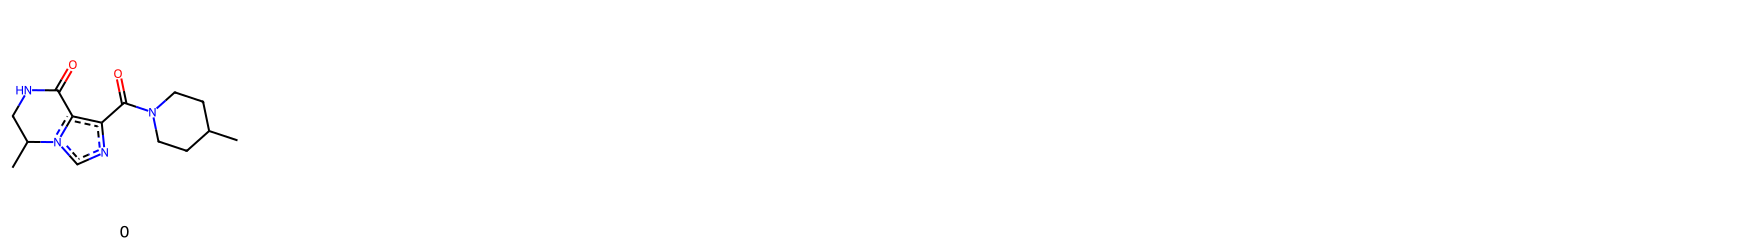

Removed top-5 most similar graphs:


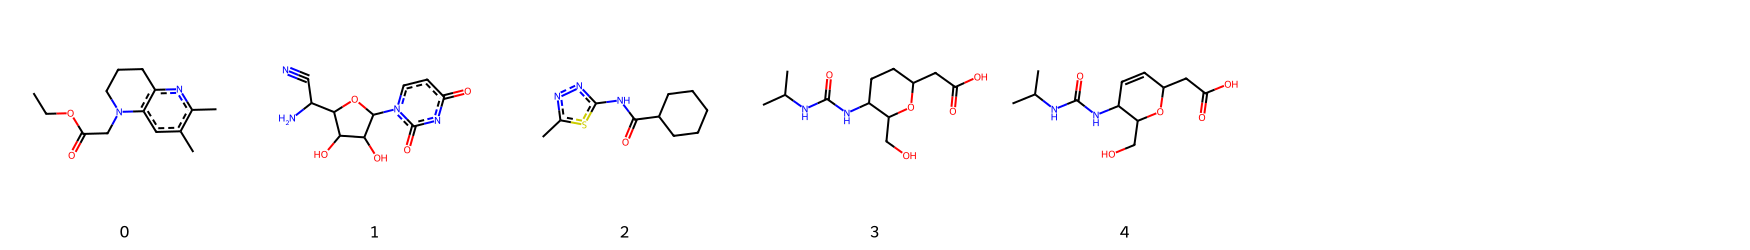

In [34]:
display_mode = infer_display_mode(graphs)

print("Anchor graph:")
plot_networkx_graphs([result['anchor_graph']], n_cols=1, mode=display_mode)

removed_graphs = [graphs[i] for i in result['remove_indices']]
print(f"Removed top-{len(removed_graphs)} most similar graphs:")
plot_networkx_graphs(removed_graphs, n_cols=max(1, len(removed_graphs)), mode=display_mode)


In [35]:
# Working dataset after similarity-based pruning
working_graphs = result['pruned_graphs']
working_targets = result['pruned_targets']
working_similarity_target = result['pruned_similarity_target']

print(f"working_graphs: {len(working_graphs)}")
print(f"working_targets: {len(working_targets)}")
print(f"working_similarity_target shape: {working_similarity_target.shape}")
print(f"cosine target range: [{working_similarity_target.min():.4f}, {working_similarity_target.max():.4f}]")


working_graphs: 31
working_targets: 31
working_similarity_target shape: (31,)
cosine target range: [0.5294, 1.0000]


## Strict CFG Experiment: Similarity to Hidden Target Graph

Train `EqMDecompositionalGraphGenerator` on the pruned dataset with the regression target
`working_similarity_target`, then generate with `desired_target=1.0` and `desired_target=0.7`
and compare average cosine similarity to the hidden anchor graph.


In [36]:
import sys
from pathlib import Path

for _root in [Path.cwd(), *Path.cwd().parents[:2]]:
    if (_root / 'eqm_decompositional_graph_generator').exists():
        _root_str = str(_root.resolve())
        if _root_str not in sys.path:
            sys.path.insert(0, _root_str)
        break
else:
    raise ModuleNotFoundError("Could not locate 'eqm_decompositional_graph_generator' package from current working directory.")

del _root, _root_str

from NSPPK.nsppk import NSPPK, NodeNSPPK
from AbstractGraph.abstract_graph_operators import compose, cycle, neighborhood, unlabel
from AbstractGraph.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
    WithinRangeFeasibilityEstimatorFromNumericalFunction,
)
from eqm_decompositional_graph_generator.eqm_conditional_node_generator import EqMDecompositionalNodeGenerator
from eqm_decompositional_graph_generator.graph_generator import (
    EqMDecompositionalGraphDecoder,
    EqMDecompositionalGraphGenerator,
)


In [37]:
# CFG experiment configuration
GEN_NBITS = 11
GEN_VERBOSE = 1
GEN_MAX_EPOCHS = 120
GEN_BATCH_SIZE = 16
GEN_TOTAL_STEPS = 100

EVAL_N_SAMPLES = 64
EVAL_GUIDANCE_SCALE = 2.0
TARGET_HIGH = 1.0
TARGET_LOW = 0.7


def build_similarity_graph_generator(nbits=11, verbose=1, maximum_epochs=120, batch_size=16, total_steps=100):
    node_graph_vectorizer = NodeNSPPK(
        radius=2,
        distance=4,
        connector=1,
        nbits=nbits,
        dense=True,
        parallel=True,
        use_edges_as_features=True,
    )
    graph_vectorizer = NSPPK(
        radius=2,
        distance=4,
        connector=1,
        nbits=nbits,
        dense=True,
        parallel=True,
        use_edges_as_features=True,
    )

    feasibility_size = WithinRangeFeasibilityEstimatorFromNumericalFunction(
        numerical_function=lambda graph: len(graph),
        quantile=None,
    )
    feasibility_unlabeled_structure = FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        nbits=19,
        parallel=True,
        backend='dill',
    )
    feasibility_valence = FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        nbits=19,
        parallel=True,
        backend='dill',
    )
    feasibility_cycle = FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(),
        nbits=19,
        parallel=True,
        backend='dill',
    )
    feasibility_estimator = FeasibilityEstimator(
        [feasibility_size, feasibility_valence, feasibility_cycle, feasibility_unlabeled_structure]
    )

    conditional_node_generator_model = EqMDecompositionalNodeGenerator(
        latent_embedding_dimension=128,
        number_of_transformer_layers=4,
        transformer_attention_head_count=4,
        transformer_dropout=0.2,
        learning_rate=1e-4,
        maximum_epochs=maximum_epochs,
        batch_size=batch_size,
        total_steps=total_steps,
        lambda_degree_importance=5e3,
        lambda_node_exist_importance=0,
        lambda_node_label_importance=5e4,
        lambda_edge_label_importance=5e3,
        lambda_locality_importance=1e4,
        degree_temperature=1,
        eqm_sigma=0.2,
        sampling_step_size=0.05,
        langevin_noise_scale=0.0,
        verbose=verbose,
        verbose_epoch_interval=10,
        enable_early_stopping=True,
        early_stopping_monitor='val_total',
        early_stopping_mode='min',
        early_stopping_patience=20,
        early_stopping_min_delta=1e-4,
        restore_best_checkpoint=True,
        cfg_condition_dropout_prob=0.1,
        cfg_null_target_strategy='zero',
        target_classification_max_distinct=20,
    )

    graph_decoder = EqMDecompositionalGraphDecoder(verbose=verbose)

    return EqMDecompositionalGraphGenerator(
        graph_vectorizer=graph_vectorizer,
        node_graph_vectorizer=node_graph_vectorizer,
        conditional_node_generator_model=conditional_node_generator_model,
        graph_decoder=graph_decoder,
        verbose=verbose,
        locality_sample_fraction=0.5,
        locality_horizon=1,
        negative_sample_factor=1,
        locality_sampling_strategy='stratified_preserve',
        locality_target_positive_ratio=0.5,
        feasibility_estimator=feasibility_estimator,
        use_feasibility_filtering=True,
        max_feasibility_attempts=10,
        feasibility_candidates_per_attempt=4,
        feasibility_failure_mode='return_partial',
    )


def cosine_to_hidden_target(graphs_to_compare, hidden_graph, fitted_graph_vectorizer):
    if len(graphs_to_compare) == 0:
        return np.array([], dtype=float)
    hidden_embedding = np.asarray(fitted_graph_vectorizer.transform([hidden_graph]), dtype=np.float32)
    generated_embeddings = np.asarray(fitted_graph_vectorizer.transform(graphs_to_compare), dtype=np.float32)
    return cosine_similarity(generated_embeddings, hidden_embedding).ravel()


Training on 31 pruned graphs with similarity targets in [0.5294, 1.0000]
Fitting model on 31 graphs
Fitting feasibility estimator on 31 graphs
Supervision plan:
  node_labels: mode=learned, enabled. 7 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 3546 pairs (50.00%) from 7092 total pairs (pos=2364, neg=4728, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=1182, neg=2364, positive_ratio=0.333.
Training conditional model on 31 graphs with up to 20 nodes each.
Using direct-edge supervision with 3546 labelled pairs.
Direct edge supervision enabled: horizon-1 edge presence will be learned

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                               ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layernorm_in                       │ LayerNorm  │  4.1 K │ train │     0 │
│ 1 │ linear_encoder_input_to_latent     │ Linear     │  262 K │ train │     0 │
│ 2 │ linear_encoder_condition_to_latent │ Linear     │  262 K │ train │     0 │
│ 3 │ shared_transformer                 │ ModuleList │  1.1 M │ train │     0 │
│ 4 │ potential_head                     │ Sequential │ 16.9 K │ train │     0 │
│ 5 │ degree_head                        │ Linear     │    645 │ train │     0 │
│ 6 │ exist_head                         │ Linear     │    129 │ train │     0 │
│ 7 │ node_label_head                    │ Linear     │    903 │ train │     0 │
│ 8 │ edge_label_head                    │ EdgeMLP    │  132 K │ train │     0 │
│ 9 │ edge_head                          │ EdgeMLP    │  131 K │ train │     0 │
└───┴────────────────────────────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.9 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 88                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=120` reached.


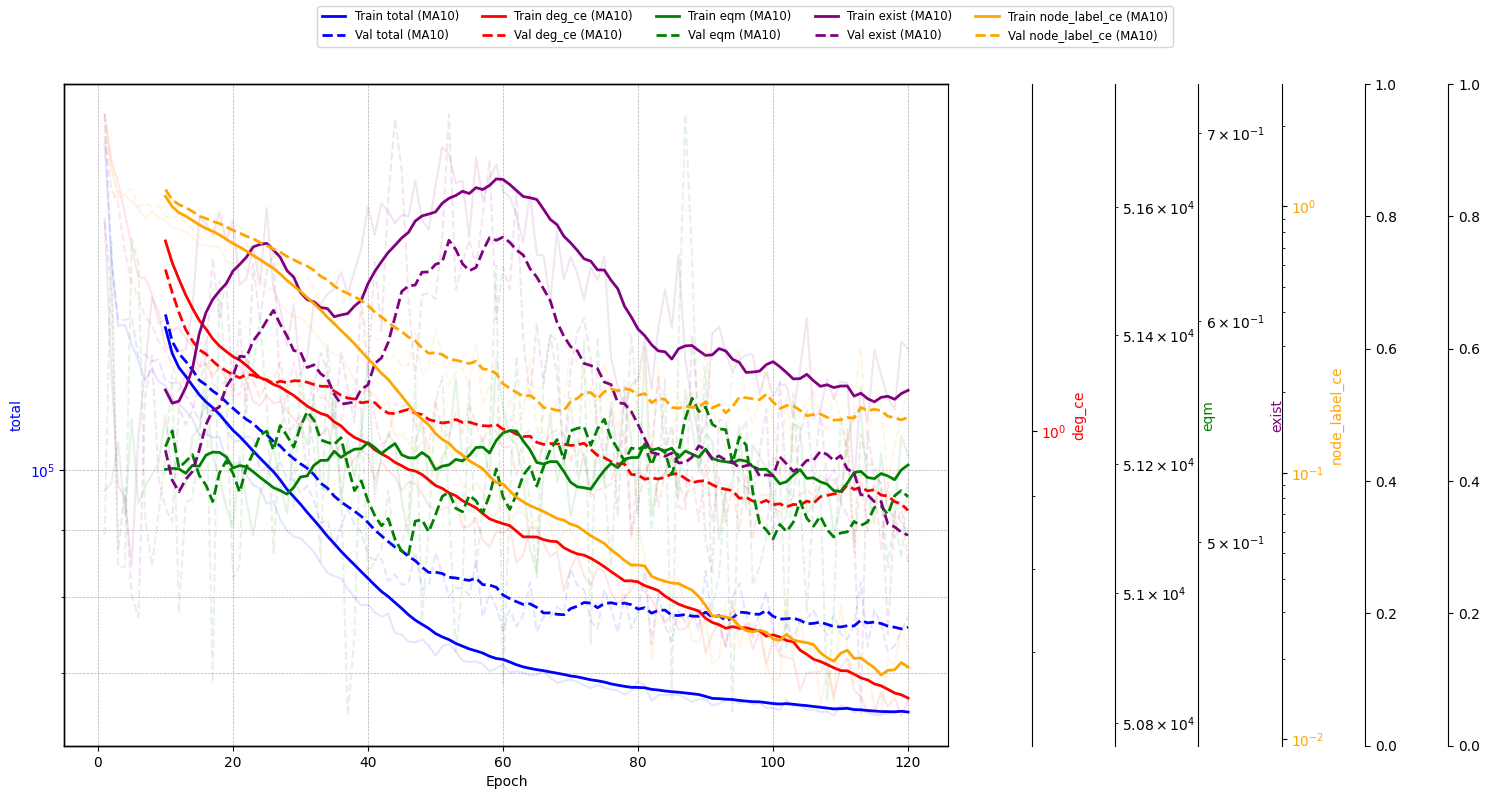

Restored best checkpoint from /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/checkpoints/eqm/EqMDecompositionalNodeGenerator_657bfb3934e04a96b6396e14500f9528/best-115-72739.4297.ckpt (best_epoch=116, val_total=72739.4297, stopped_epoch=121).


In [38]:
similarity_graph_generator = build_similarity_graph_generator(
    nbits=GEN_NBITS,
    verbose=GEN_VERBOSE,
    maximum_epochs=GEN_MAX_EPOCHS,
    batch_size=GEN_BATCH_SIZE,
    total_steps=GEN_TOTAL_STEPS,
)

print(f"Training on {len(working_graphs)} pruned graphs with similarity targets in [{working_similarity_target.min():.4f}, {working_similarity_target.max():.4f}]")
_ = similarity_graph_generator.fit(
    working_graphs,
    targets=working_similarity_target,
)


In [ ]:
generated_high = similarity_graph_generator.sample_conditioned_on_random(
    working_graphs,
    n_samples=EVAL_N_SAMPLES,
    desired_target=TARGET_HIGH,
    guidance_scale=EVAL_GUIDANCE_SCALE,
    apply_feasibility_filtering=False,
)

generated_low = similarity_graph_generator.sample_conditioned_on_random(
    working_graphs,
    n_samples=EVAL_N_SAMPLES,
    desired_target=TARGET_LOW,
    guidance_scale=EVAL_GUIDANCE_SCALE,
    apply_feasibility_filtering=False,
)

sim_high = cosine_to_hidden_target(generated_high, result['anchor_graph'], graph_vectorizer)
sim_low = cosine_to_hidden_target(generated_low, result['anchor_graph'], graph_vectorizer)

summary = pd.DataFrame([
    {
        'group': f'desired_target={TARGET_HIGH}',
        'n_generated': len(generated_high),
        'mean_cosine_to_hidden': float(sim_high.mean()) if len(sim_high) else np.nan,
        'std_cosine_to_hidden': float(sim_high.std()) if len(sim_high) else np.nan,
    },
    {
        'group': f'desired_target={TARGET_LOW}',
        'n_generated': len(generated_low),
        'mean_cosine_to_hidden': float(sim_low.mean()) if len(sim_low) else np.nan,
        'std_cosine_to_hidden': float(sim_low.std()) if len(sim_low) else np.nan,
    },
])

display(summary)

if len(sim_high) and len(sim_low):
    print(f"mean(high) - mean(low) = {sim_high.mean() - sim_low.mean():.4f}")
    if sim_high.mean() > sim_low.mean():
        print('Observed ordering: desired_target=1.0 is closer on average to the hidden target than desired_target=0.7.')
    else:
        print('Observed ordering: desired_target=1.0 is not closer on average in this run; increase samples or retrain.')



In [ ]:
display_mode = infer_display_mode(working_graphs)

print('Sample generations for desired_target=1.0')
plot_networkx_graphs(generated_high[:6], n_cols=min(6, max(1, len(generated_high[:6]))), mode=display_mode)

print('Sample generations for desired_target=0.7')
plot_networkx_graphs(generated_low[:6], n_cols=min(6, max(1, len(generated_low[:6]))), mode=display_mode)
